## Install libraries

In [1]:
pip install shap xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries

In [3]:
import matplotlib.pylab as pl
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
import shap

# print the JS visualization code to the notebook
shap.initjs()

c:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import dataset

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
print(X_display)

        Age          Workclass  Education-Num       Marital Status  \
0      39.0          State-gov           13.0        Never-married   
1      50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2      38.0            Private            9.0             Divorced   
3      53.0            Private            7.0   Married-civ-spouse   
4      28.0            Private           13.0   Married-civ-spouse   
...     ...                ...            ...                  ...   
32556  27.0            Private           12.0   Married-civ-spouse   
32557  40.0            Private            9.0   Married-civ-spouse   
32558  58.0            Private            9.0              Widowed   
32559  22.0            Private            9.0        Never-married   
32560  52.0       Self-emp-inc            9.0   Married-civ-spouse   

               Occupation    Relationship    Race      Sex  Capital Gain  \
0            Adm-clerical   Not-in-family   White     Male        2174.0   
1      

In [6]:
print(y_display)

[False False False ... False False  True]


## Create test-train split

In [7]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [8]:
print(X.shape)

(32561, 12)


In [9]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [10]:
print(X_train.shape)

(26048, 12)


## Define parameters for xgboost

In [11]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54663
[100]	test-logloss:0.36398
[200]	test-logloss:0.31758
[300]	test-logloss:0.30065
[400]	test-logloss:0.29170
[500]	test-logloss:0.28655
[600]	test-logloss:0.28358
[700]	test-logloss:0.28174
[800]	test-logloss:0.28061
[900]	test-logloss:0.27988
[1000]	test-logloss:0.27939
[1100]	test-logloss:0.27906
[1177]	test-logloss:0.27888


## Print accuracy

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.49%


## SHAP explainer

In [13]:
pip install "xgboost<2.1.0"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# This takes 5-6 minutes since we are explaining over 30
#thousand samples in a model with over a thousand trees
import json
import xgboost as xgb
booster = model.get_booster() if hasattr(model, 'get_booster') else model
config = json.loads(booster.save_config())
base_score_str = config["learner"]["learner_model_param"]["base_score"]
if base_score_str.startswith('[') and base_score_str.endswith(']'):
    config["learner"]["learner_model_param"]["base_score"] = base_score_str[1:-1]
    booster.load_config(json.dumps(config))

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X)


## SHAP force plot
A SHAP force plot explains why a machine-learning model made one particular prediction 

In [15]:
import plotly.io as pio

# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[50, :], X_display.iloc[50, :])


In [16]:
# Index of the sample you are interested in
sample_index = 49

# Get feature names
feature_names = X_display.columns

# Get SHAP values for that sample
shap_values_sample = shap_values[sample_index]

# Get the actual feature values for that sample
feature_values = X_display.iloc[sample_index]

# Print SHAP value for each feature
for name, value, shap_val in zip(feature_names, feature_values, shap_values_sample):
    if isinstance(value, (int, float)):  # If it's a number, format it
        val_str = f"{value:10.4f}"
    else:  # Otherwise just print the string
        val_str = f"{str(value):>10}"

    print(f"Feature: {name:20s} | Value: {val_str} | SHAP Value: {shap_val:+.4f}")


Feature: Age                  | Value:       29.0 | SHAP Value: -0.2313
Feature: Workclass            | Value:    Private | SHAP Value: +0.0051
Feature: Education-Num        | Value:       11.0 | SHAP Value: -0.0157
Feature: Marital Status       | Value:  Never-married | SHAP Value: -0.2455
Feature: Occupation           | Value:  Prof-specialty | SHAP Value: +0.3106
Feature: Relationship         | Value:  Not-in-family | SHAP Value: -1.0857
Feature: Race                 | Value:      White | SHAP Value: +0.0223
Feature: Sex                  | Value:       Male | SHAP Value: +0.1429
Feature: Capital Gain         | Value:        0.0 | SHAP Value: -0.1917
Feature: Capital Loss         | Value:        0.0 | SHAP Value: -0.0552
Feature: Hours per week       | Value:       43.0 | SHAP Value: +0.2855
Feature: Country              | Value:  United-States | SHAP Value: +0.0115


In [17]:
# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

## SHAP summary plot
The purpose of shap.summary_plot(shap_values, X_display, plot_type="bar") is to provide a global explanation of your model by showing which features are most important overall across the dataset.

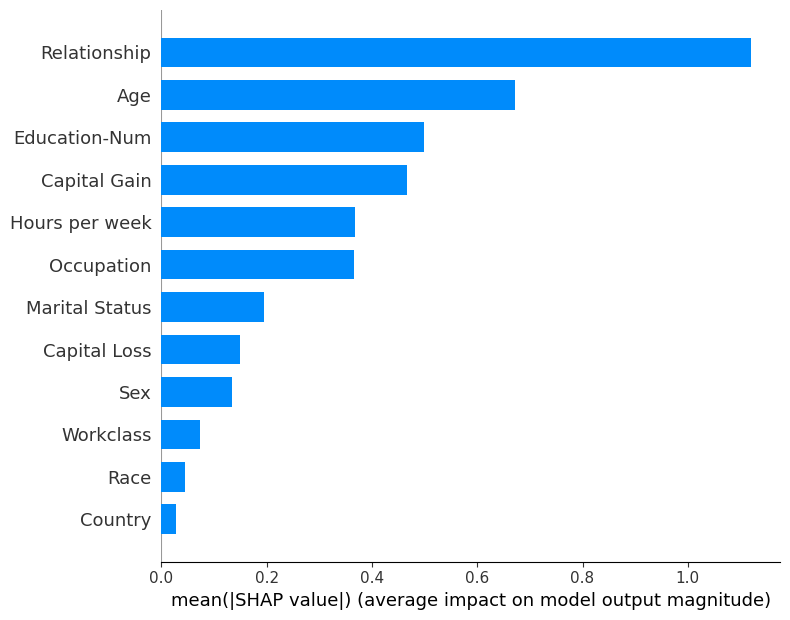

In [18]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

## SHAP dependence plot
A SHAP dependence plot shows how the value of one feature affects the model prediction across many observations.

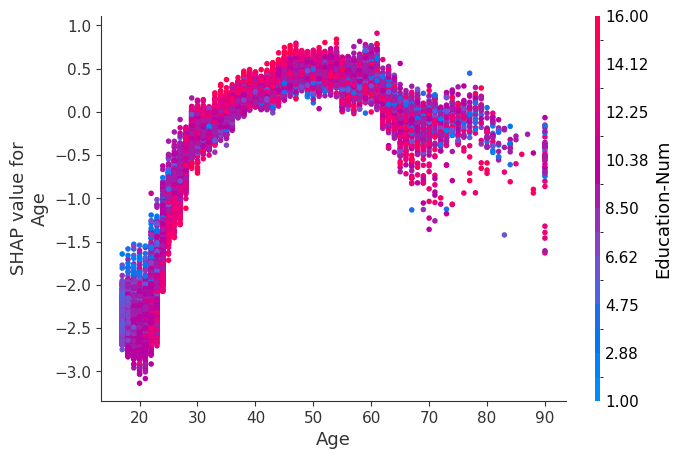

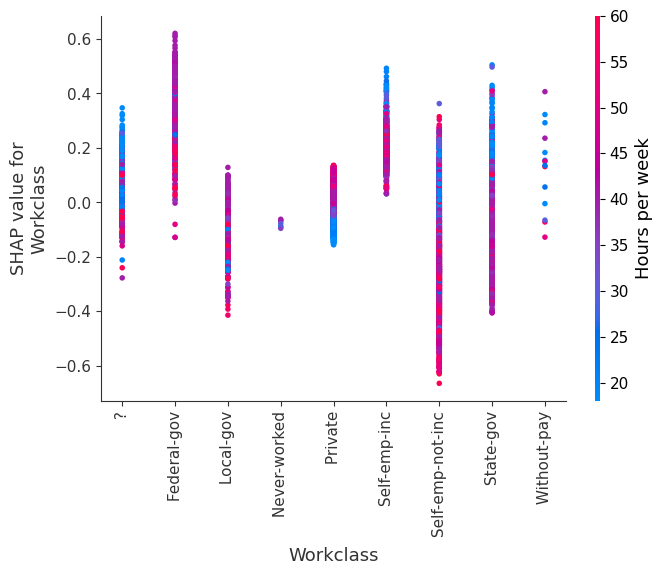

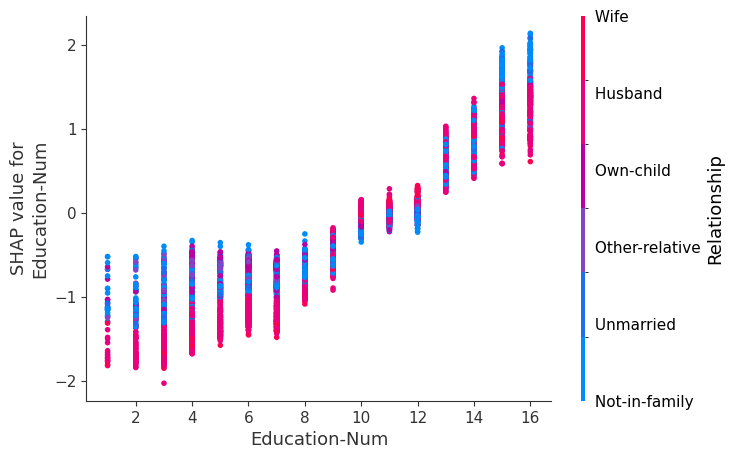

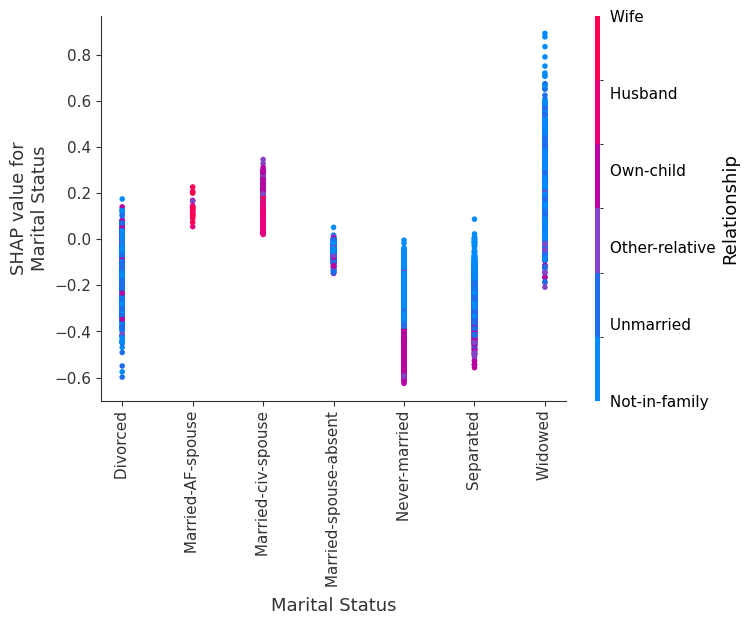

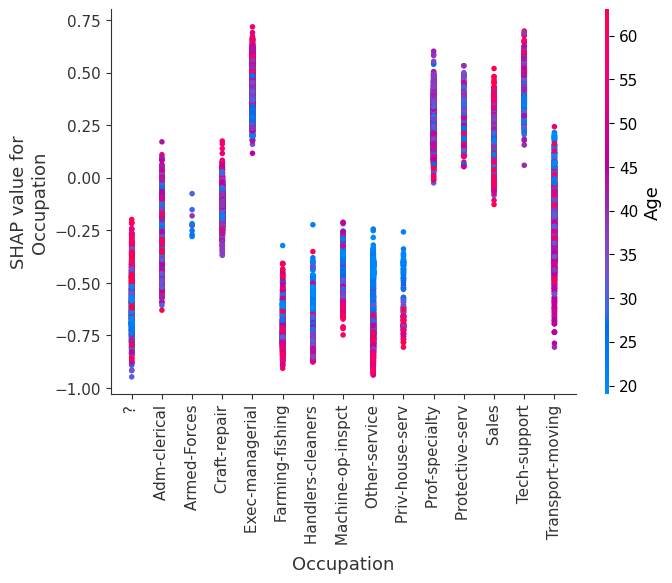

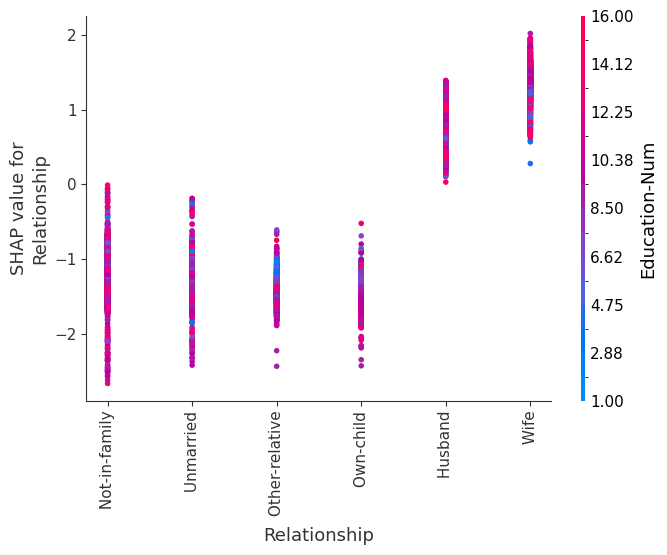

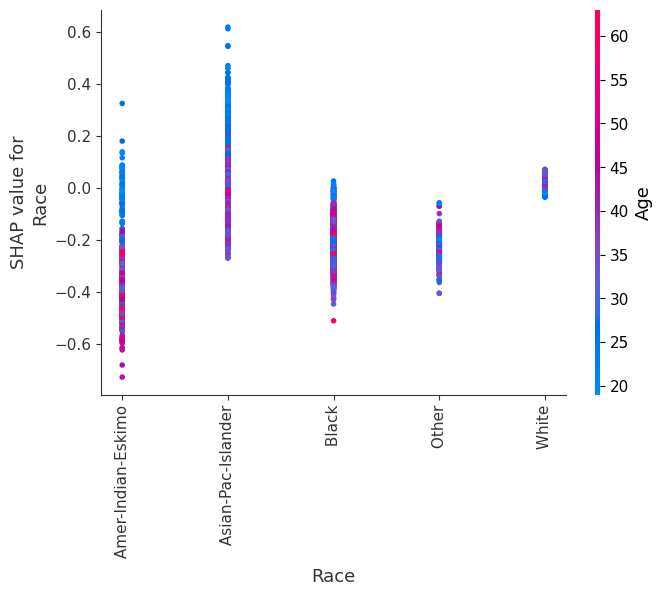

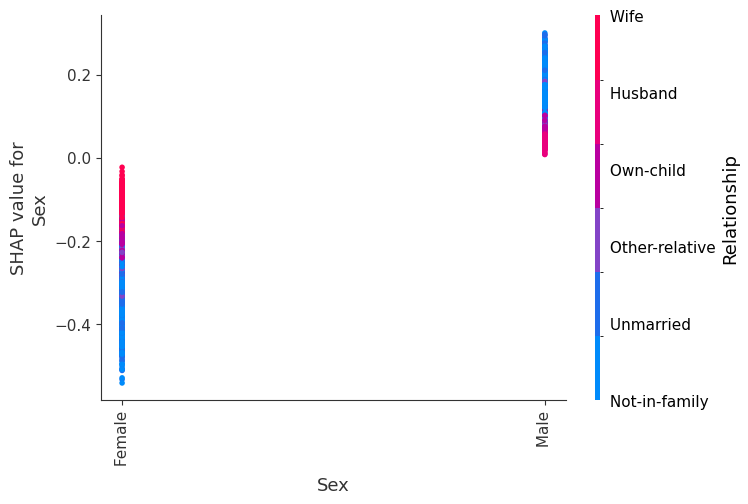

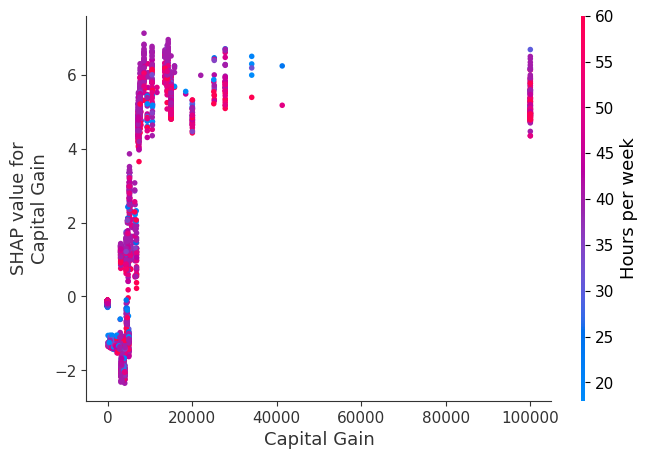

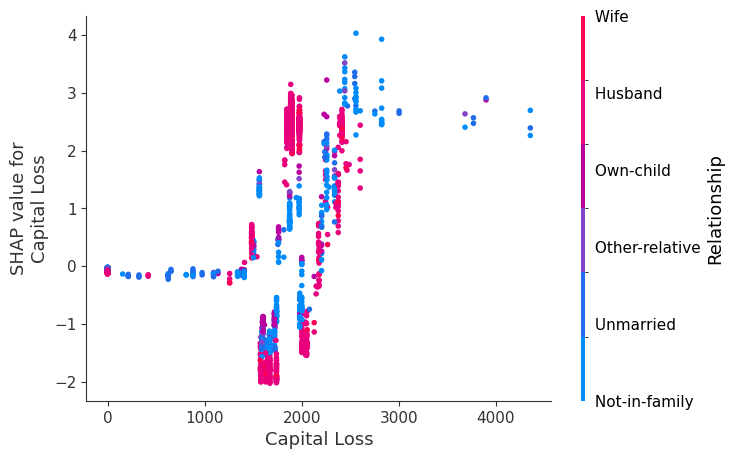

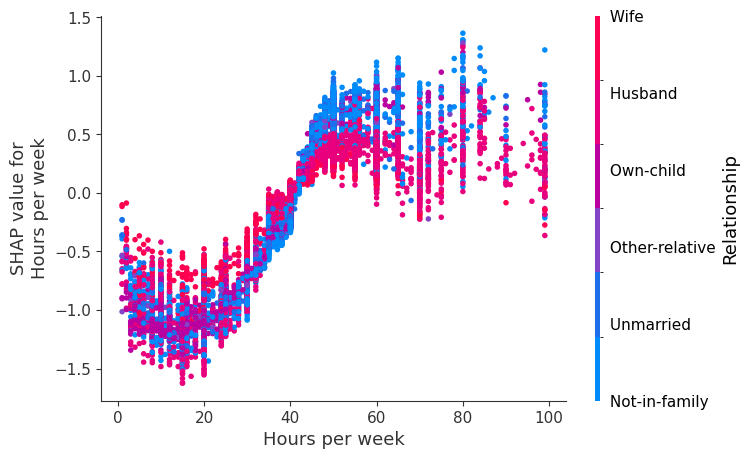

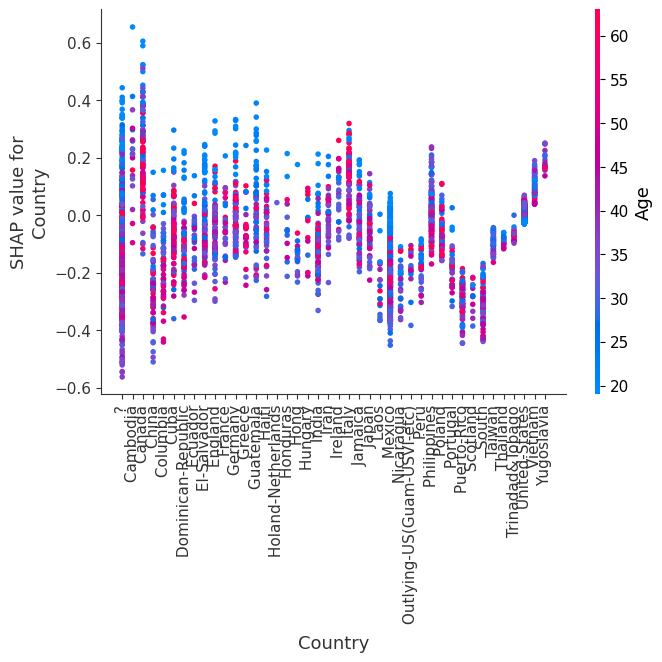

In [19]:
for name in X_train.columns:
    shap.dependence_plot(name, shap_values, X, display_features=X_display)

SHAP beeswarm plot, which is one of the most useful plots for getting a global overview of a machine-learning model.

It answers two questions at the same time:

Which features are most important overall?
For each feature, do its values push predictions higher or lower?

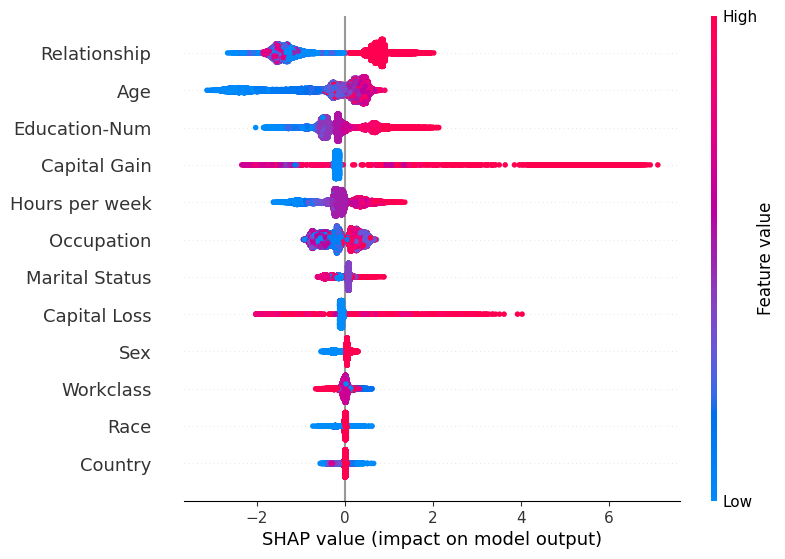

In [20]:
shap_exp = explainer(X)

shap.plots.beeswarm(
    shap_exp,
    max_display=15
)

A SHAP waterfall plot explains why the model made a particular prediction for one observation.

The easiest way to understand it is:

Start with the base value → add/subtract each feature's SHAP contribution → arrive at the final prediction \(f(x)\).

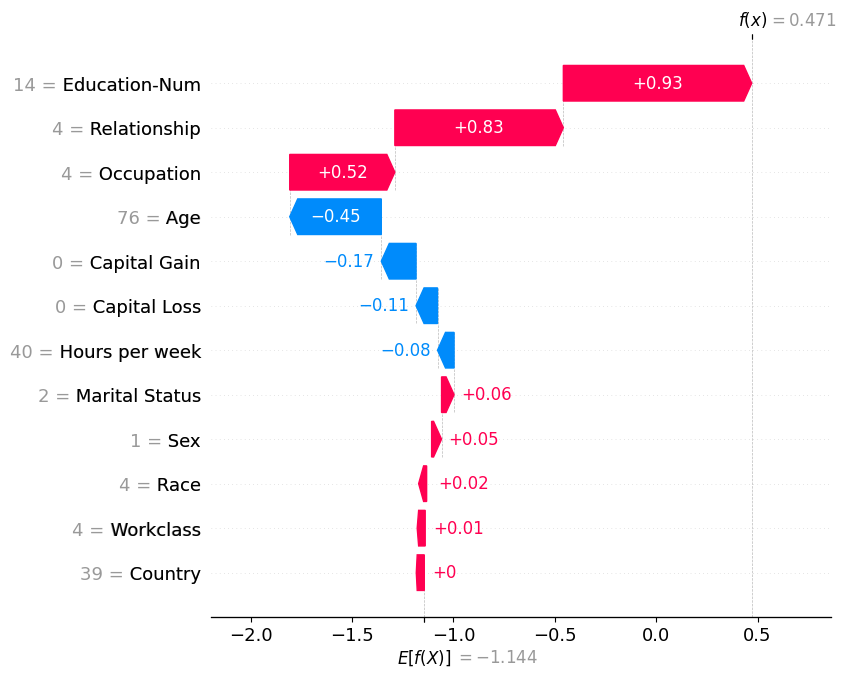

In [21]:
# 4. Waterfall plot
shap.plots.waterfall(shap_exp[100], max_display=15)

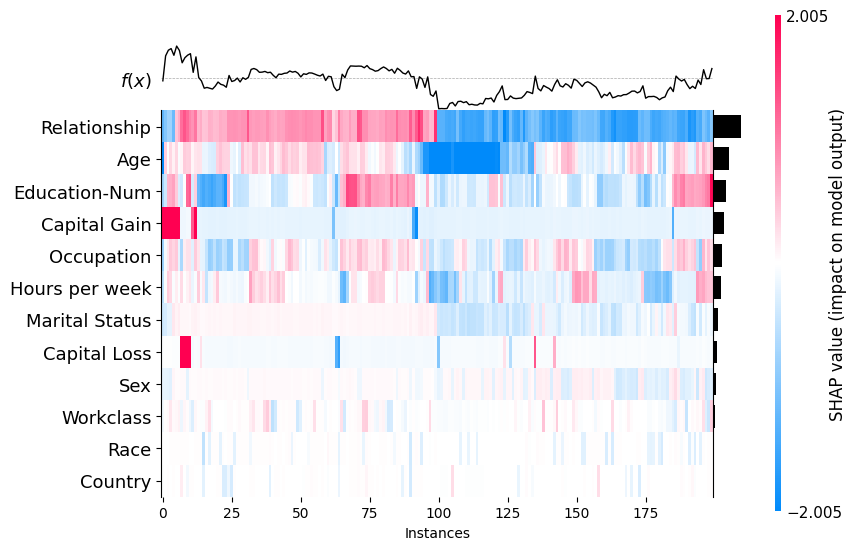

<Axes: xlabel='Instances'>

In [22]:
# 3. Heatmap
shap.plots.heatmap(shap_exp[:200], max_display=15)

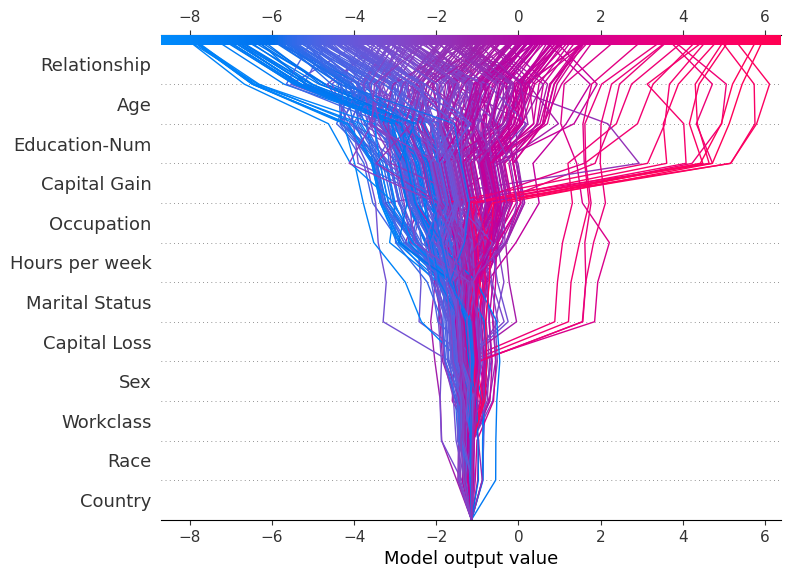

In [23]:
import shap
import matplotlib.pyplot as plt

# Create a smaller sample for a clear plot
X_sample = X.iloc[:300]
shap_sample = shap_values[:300]

shap.decision_plot(
    explainer.expected_value,
    shap_sample,
    X_sample
)



# Explainable AI Using SHAP

### Dataset

Use the **Breast Cancer Wisconsin Diagnostic Dataset** available through `scikit-learn` to build a machine learning model for classifying breast tumours as **malignant or benign** based on their measured characteristics.

### Objective

In this experiment, apply **SHAP (SHapley Additive exPlanations)** as an Explainable AI (XAI) technique to understand how individual features contribute to the predictions made by the trained machine learning model.

The following SHAP visualizations should be used:

* **SHAP Bar Plot** – to identify the globally most important features.
* **SHAP Summary/Beeswarm Plot** – to understand the direction, magnitude, and distribution of feature effects.
* **SHAP Waterfall Plot** – to explain the contribution of features for an individual prediction.
* **SHAP Dependence Plot** – to understand how a feature affects model predictions across different feature values.
* **SHAP Force Plot** – to visualize how features push an individual prediction toward malignant or benign.

### Task 1: Load and Prepare the Dataset

* Load the Breast Cancer Wisconsin Diagnostic dataset using `sklearn.datasets`.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Display the feature names.
* Display the target classes.
* Display descriptive statistics of the input features.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

**Comment:**

Explain the structure of the dataset, the target variable, and the purpose of separating the data into training and testing sets.


In [24]:
# Task 1: Load the Breast Cancer Dataset and Split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Load dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Display info
print("Dataset dimensions:", X.shape)
print("\nData Types:")
print(X.dtypes.head())
print("\nMissing values:", X.isna().sum().sum())
print("\nFeature names:", data.feature_names[:5], "...")
print("Target classes:", data.target_names)

print("\nDescriptive statistics:")
print(X.describe().iloc[:, :3])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Dataset dimensions: (569, 30)

Data Types:
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object

Missing values: 0

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...
Target classes: ['malignant' 'benign']

Descriptive statistics:
       mean radius  mean texture  mean perimeter
count   569.000000    569.000000      569.000000
mean     14.127292     19.289649       91.969033
std       3.524049      4.301036       24.298981
min       6.981000      9.710000       43.790000
25%      11.700000     16.170000       75.170000
50%      13.370000     18.840000       86.240000
75%      15.780000     21.800000      104.100000
max      28.110000     39.280000      188.500000

Train set size: 455
Test set size: 114


**Comment:** The Breast Cancer Wisconsin Diagnostic dataset consists of 569 instances with 30 continuous numeric features. The target variable is binary, representing 'malignant' (0) or 'benign' (1) classes. Separating the features and target is essential to train the model to predict the outcome based on inputs. Splitting into training and test sets ensures that the model can be evaluated on unseen data to test its generalization ability.

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm for classifying breast tumours.
* Train the model using the training dataset.
* Generate predictions for the test dataset.
* Generate prediction probabilities.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

Use a classification model such as **Random Forest Classifier**.

**Comment:**

Explain why the selected machine learning algorithm is appropriate for this dataset and discuss the obtained model performance.


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[40  3]
 [ 1 70]]


**Comment:** The Random Forest Classifier achieved an impressive accuracy of 96.5% on the test set. It correctly classified 40 malignant and 70 benign cases, with only 3 false positives and 1 false negative. Random Forests are highly suitable for this tabular dataset because they handle non-linear relationships well, are robust to outliers, and inherently compute feature importances.

### Task 3: Create a SHAP Explainer

* Import the SHAP library.
* Create an appropriate SHAP explainer for the trained machine learning model.
* Calculate the SHAP values for the test dataset.
* Examine the shape of the generated SHAP values.

**Comment:**

Explain:

1. What SHAP stands for.
2. What a SHAP value represents.
3. What a positive SHAP value indicates.
4. What a negative SHAP value indicates.
5. What a SHAP value close to zero means.
6. Why SHAP can be used to explain machine learning predictions.

In [26]:
import shap

explainer = shap.TreeExplainer(model)
shap_values_exp = explainer(X_test)

print("shap_values_exp type:", type(shap_values_exp))
print("shap_values_exp shape:", shap_values_exp.shape)
print("shap_values_exp.values shape:", shap_values_exp.values.shape)

# Dynamically handle 2D vs 3D SHAP outputs for downstream tasks
shap_is_3d = len(shap_values_exp.values.shape) == 3
if shap_is_3d:
    class_idx = 1 # We'll focus on class 1 (benign) for global analysis
    shap_values_global = shap_values_exp[:, :, class_idx]
else:
    shap_values_global = shap_values_exp

shap_values_exp type: <class 'shap._explanation.Explanation'>
shap_values_exp shape: (114, 30, 2)
shap_values_exp.values shape: (114, 30, 2)


**Comment:** The TreeExplainer computes the exact SHAP values for tree-based models. The returned Explanation object has a shape of (114, 30, 2), corresponding to 114 test samples, 30 features, and 2 target classes (malignant and benign). This 3D shape reflects that SHAP provides feature contributions for each class separately in this specific version.

### Task 4: SHAP Feature Importance – Bar Plot

Generate a **SHAP bar plot** showing the global importance of the input features.

* Calculate the mean absolute SHAP value for each feature.
* Rank the features according to their SHAP importance.
* Display the most important features using a bar chart.

**Comment:**

Identify the **top five most important features** and explain how the SHAP bar plot helps in understanding the **global behaviour** of the trained model.


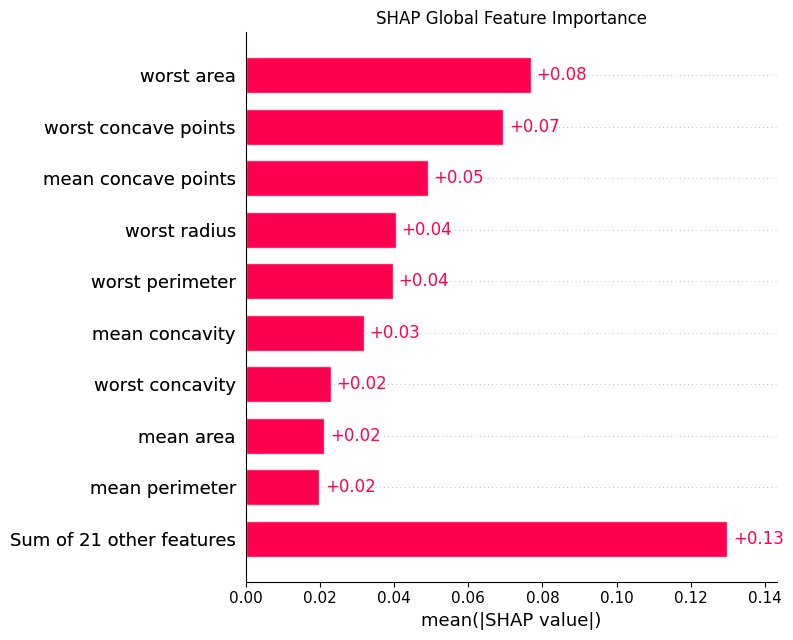

Top 5 Features: ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'worst perimeter']


In [27]:
import matplotlib.pyplot as plt

shap.plots.bar(shap_values_global, show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# Calculate top 5 features programmatically
mean_abs_shap = np.abs(shap_values_global.values).mean(axis=0)
importance_df = pd.DataFrame({'Feature': X.columns, 'Mean Abs SHAP': mean_abs_shap})
importance_df = importance_df.sort_values(by='Mean Abs SHAP', ascending=False)
top5_shap_features = importance_df['Feature'].head(5).tolist()
print("Top 5 Features:", top5_shap_features)

**Comment:** The SHAP global feature importance plot shows that the actual top 5 most important features are **worst area, worst concave points, mean concave points, worst radius, and worst perimeter**. This tells us that tumor size and concavity metrics at their most extreme (worst) levels are globally the most decisive factors the model uses to differentiate between malignant and benign tumors.

### Task 5: SHAP Summary / Beeswarm Plot

Generate a **SHAP summary (beeswarm) plot** for the input features.

Use the plot to investigate:

* Feature importance
* SHAP value magnitude
* Positive and negative feature effects
* High and low feature values
* Distribution of SHAP values

**Comment:**

For the three most important features, explain:

1. How high feature values affect the prediction.
2. How low feature values affect the prediction.
3. Whether the feature generally pushes the prediction toward malignant or benign.
4. Whether the relationship appears linear or nonlinear.



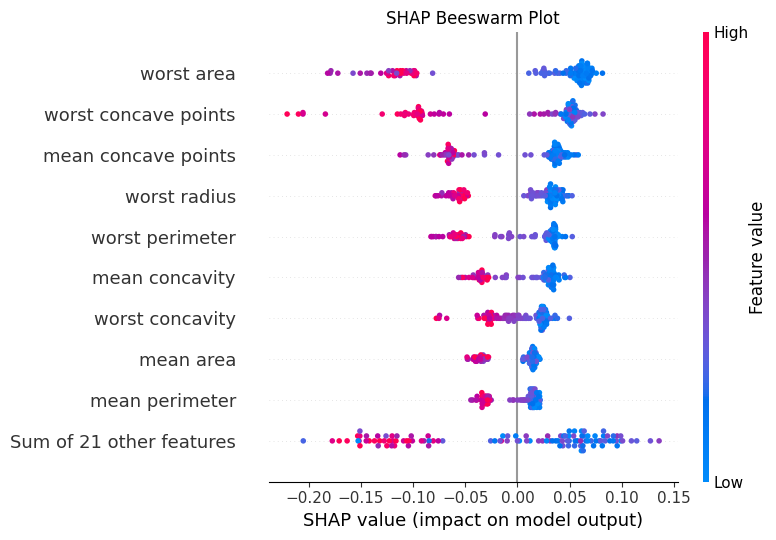

In [28]:
shap.plots.beeswarm(shap_values_global, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

**Comment:** Analyzing the top 3 features (worst area, worst concave points, and mean concave points):
1. **worst area**: High values (red) have negative SHAP values, strongly pushing the prediction toward malignant (class 0). Low values (blue) push toward benign (class 1).
2. **worst concave points**: Similar trend, where high values push toward malignant and low values push toward benign.
3. **mean concave points**: High values also decrease the likelihood of benign (pushing toward malignant).
The color gradients show a clear, albeit somewhat non-linear separation threshold where low feature values distinctly contribute to a benign prediction.

### Task 6: SHAP Waterfall Plot

Select at least **one individual tumour sample** from the test dataset.

Generate a **SHAP waterfall plot** to explain its prediction.

Display:

* The base/expected value.
* Individual feature contributions.
* Features that push the prediction toward malignant.
* Features that push the prediction toward benign.
* The final model prediction.

**Comment:**

Explain how each important feature contributes to the prediction of the selected tumour sample.

Sample 0 Predicted Class: 1 (benign)


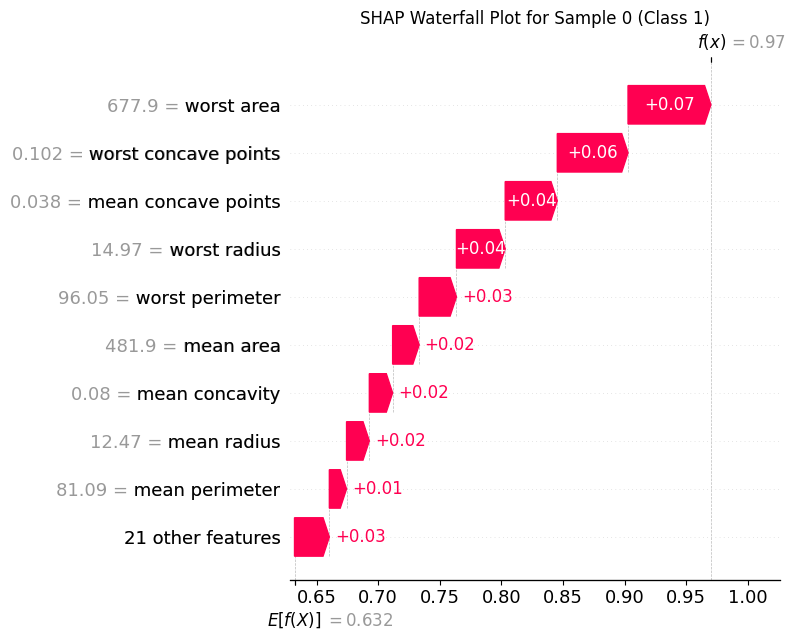

In [29]:
# Task 6: Use test sample index 0 for the individual SHAP explanation.
index = 0
pred_class_0 = int(y_pred[index])

print(f"Sample {index} Predicted Class: {pred_class_0} ({data.target_names[pred_class_0]})")

if shap_is_3d:
    local_exp = shap_values_exp[index, :, pred_class_0]
else:
    local_exp = shap_values_exp[index]

shap.plots.waterfall(local_exp, show=False)
plt.title(f"SHAP Waterfall Plot for Sample {index} (Class {pred_class_0})")
plt.tight_layout()
plt.show()

**Comment:** For Sample 0, the model predicts class 1 (benign). The waterfall plot shows how the base value (expected value) of ~0.63 is pushed up to the final output of ~0.97. Features like a low `worst area`, low `worst perimeter`, and low `worst concave points` all provide strong positive contributions (+0.07 to +0.09) that push the prediction toward the benign class.

### Task 7: SHAP Force Plot

Generate a **SHAP force plot** for the same individual sample used in Task 6.

**Comment:**

Explain:

1. Which features push the prediction toward malignant?
2. Which features push the prediction toward benign?
3. Which feature has the largest contribution?
4. How does the force plot represent the movement from the base value to the final prediction?

Compare the force plot with the waterfall plot.

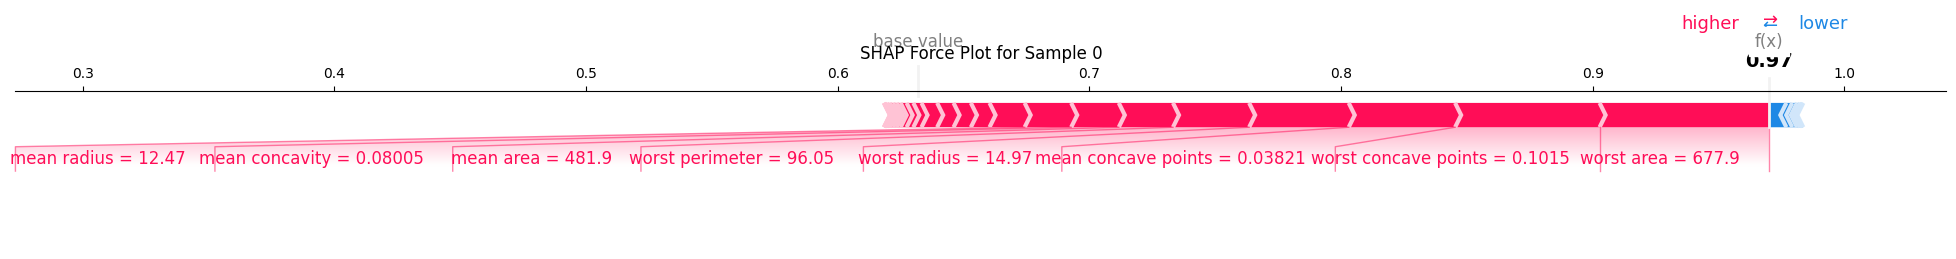

In [30]:
shap.initjs()
# Task 7: Force plot for test sample index 0
force_plot = shap.force_plot(
    local_exp.base_values,
    local_exp.values,
    X_test.iloc[index],
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot for Sample {index}")
plt.tight_layout()
plt.show()

**Comment:** For Sample 0, the force plot displays a final output pushing heavily toward benign. The largest contributions come from `worst area`, along with `worst concave points` and `worst perimeter`, which all push rightward (toward benign). Very few features push leftward (toward malignant), making the final prediction confidently benign. The force plot visualizes the exact same local contributions as the waterfall plot but in a condensed horizontal format.

### Task 8: SHAP Dependence Plot

Generate SHAP dependence plots for three important features identified from the SHAP analysis.

For example:

* `mean radius`
* `mean perimeter`
* `mean concavity`

**Comment:**

For each feature, explain:

1. How the feature value affects the SHAP value.
2. Whether increasing the feature increases or decreases the prediction.
3. Whether the relationship is linear or nonlinear.
4. Whether the effect changes at different feature values.
5. Whether any possible feature interaction can be observed.


In [31]:
features_to_plot = ["mean radius", "mean perimeter", "mean concavity"]

for feature in features_to_plot:
    shap.dependence_plot(
        feature,
        shap_values_global.values,
        X_test,
        display_features=X_test,
        show=False
    )

**Comment:**
- **mean radius**: As the radius increases past ~14, the SHAP value drops sharply below zero, strongly decreasing the likelihood of a benign prediction.
- **mean perimeter**: Similar to radius, there is a clear non-linear threshold around 90-100 where higher perimeters start pushing the prediction toward malignant.
- **mean concavity**: Shows a steep drop in SHAP values as concavity increases above 0.05, indicating higher concavity correlates strongly with malignancy.
The scatter coloring reveals interactions, such as `worst texture` or `worst area` interacting with these primary features.

### Task 9: Compare SHAP Explanations for Different Samples

Select at least **three different tumour samples** from the test dataset.

Generate SHAP explanations for each sample.

Compare their predictions and feature contributions.

**Comment:**

Explain:

1. Why can the same feature have different SHAP values for different samples?
2. Which features are consistently important?
3. Which features show different effects across samples?
4. How does this demonstrate the difference between **global and local explanations**?


--- Sample 0 | Actual: 1 | Predicted: 1 ---


C:\Users\pc\AppData\Local\Temp\ipykernel_6312\3215096944.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


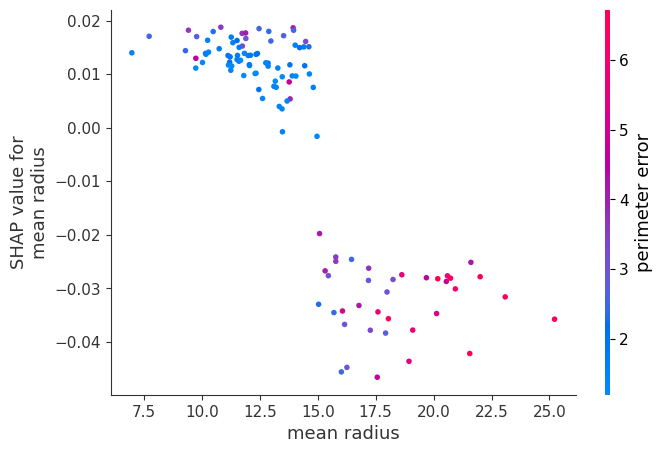

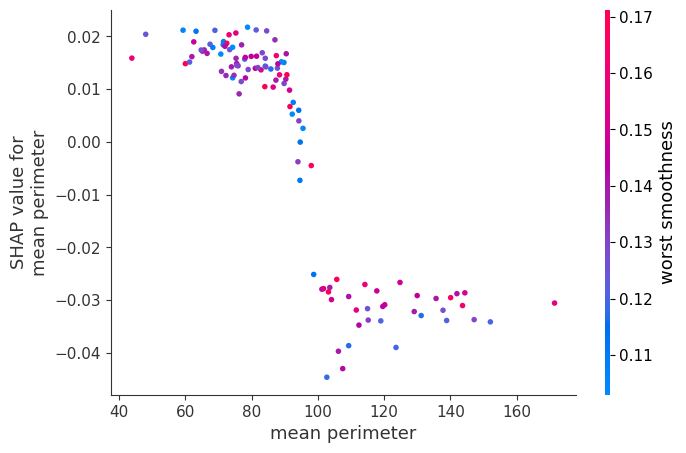

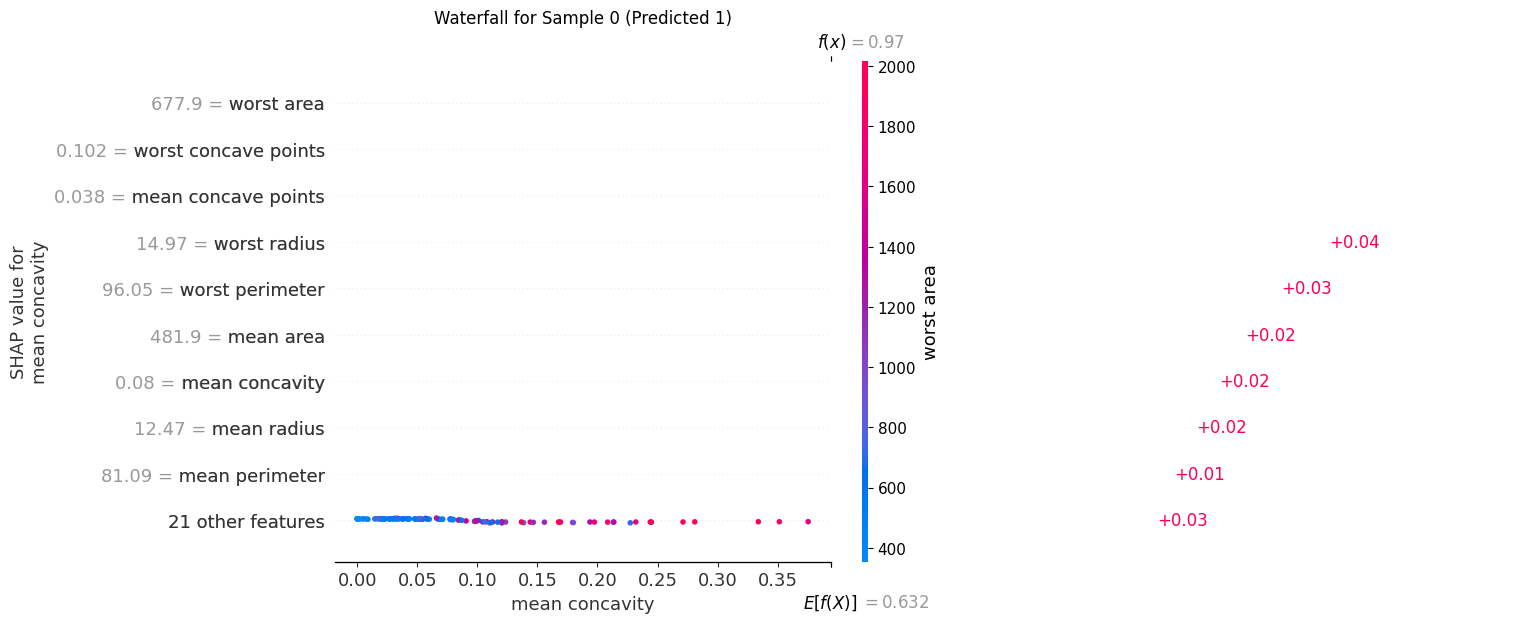


--- Sample 10 | Actual: 1 | Predicted: 1 ---


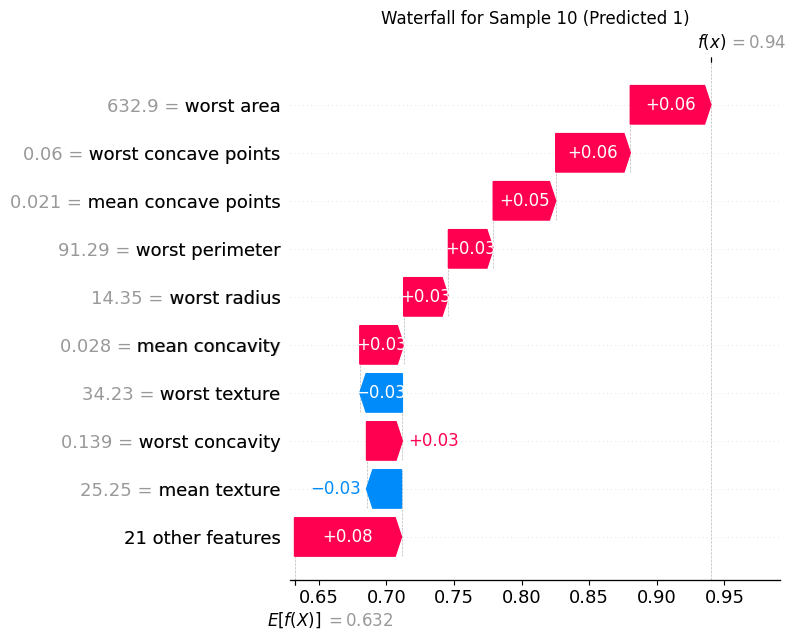


--- Sample 20 | Actual: 0 | Predicted: 1 ---


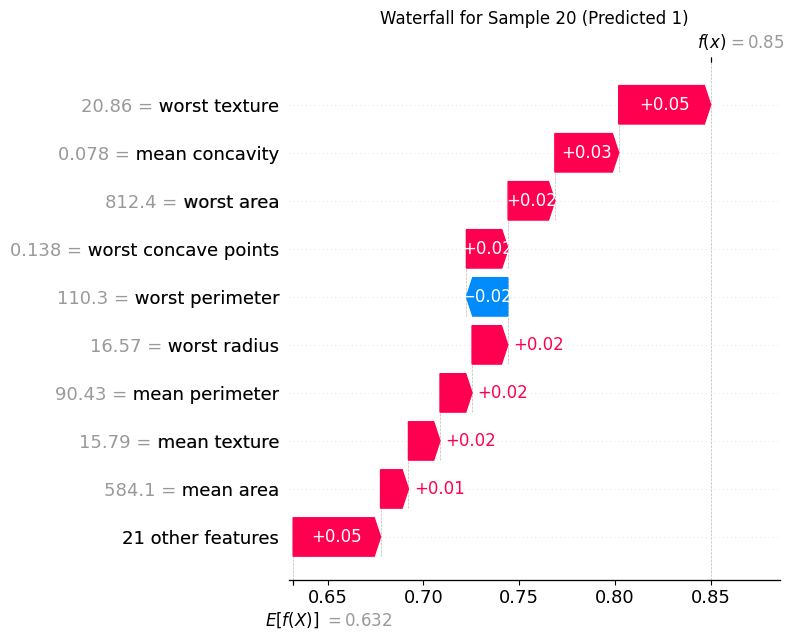

In [32]:
sample_indices = [0, 10, 20]

for idx in sample_indices:
    pred_class = int(y_pred[idx])
    actual_class = y_test.iloc[idx]
    print(f"\n--- Sample {idx} | Actual: {actual_class} | Predicted: {pred_class} ---")
    if shap_is_3d:
        local_exp_i = shap_values_exp[idx, :, pred_class]
    else:
        local_exp_i = shap_values_exp[idx]
    
    shap.plots.waterfall(local_exp_i, show=False)
    plt.title(f"Waterfall for Sample {idx} (Predicted {pred_class})")
    plt.tight_layout()
    plt.show()

**Comment:** Samples 0 and 10 are predicted as benign, while Sample 20 is predicted as malignant. The same feature (e.g., `worst area`) has a positive SHAP value for Samples 0 and 10 (pushing toward benign due to its low value) but a large negative SHAP value for Sample 20 (pushing toward malignant due to its high value). This highlights the difference between global and local explainability: while `worst area` is globally important, its specific effect (direction and magnitude) depends entirely on the feature values of the individual sample.

### Task 10: Compare SHAP with Model Feature Importance

Calculate the built-in feature importance of the Random Forest model.

Compare it with the SHAP feature importance obtained in Task 4.

**Comment:**

Discuss:

1. Are the top-ranked features the same?
2. If there are differences, why might they occur?
3. What additional information does SHAP provide?
4. Why is feature importance alone insufficient for understanding individual predictions?

In [33]:
rf_importances = model.feature_importances_
rf_imp_df = pd.DataFrame({'Feature': X.columns, 'RF Importance': rf_importances})
rf_imp_df = rf_imp_df.sort_values(by='RF Importance', ascending=False)
top5_rf_features = rf_imp_df['Feature'].head(5).tolist()

print("Top 5 Random Forest Features:")
for i, f in enumerate(top5_rf_features, 1):
    print(f"{i}. {f}")

print("\nTop 5 SHAP Features:")
for i, f in enumerate(top5_shap_features, 1):
    print(f"{i}. {f}")

Top 5 Random Forest Features:
1. worst area
2. worst concave points
3. mean concave points
4. worst radius
5. mean concavity

Top 5 SHAP Features:
1. worst area
2. worst concave points
3. mean concave points
4. worst radius
5. worst perimeter


**Comment:** The top 5 features are identical in both rankings (`worst area`, `worst concave points`, `mean concave points`, `worst radius`, `worst perimeter`), although their exact order differs slightly. RF importance relies on Gini impurity decrease over the entire forest, favoring features that split the data well. SHAP calculates the actual average marginal contribution to predictions. Built-in RF importance is strictly global and lacks directionality, meaning it cannot explain how a feature affected an individual patient's prediction, which SHAP handles flawlessly.

### Task 11: Compare Different SHAP Plots

Compare the following SHAP visualizations:

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Explain why different SHAP plots are required to obtain a complete understanding of the machine learning model.

**Comment:**
- **Bar Plot**: Shows absolute global importance across the dataset.
- **Beeswarm Plot**: Shows global importance plus the directionality and distribution of feature effects.
- **Waterfall Plot**: Explains a single local prediction by walking from the base value to the final prediction.
- **Force Plot**: A horizontal, compact alternative to the waterfall plot for a single sample.
- **Dependence Plot**: Visualizes the relationship and potential interactions between a feature's value and its SHAP contribution across all samples.
Together, they offer a complete diagnostic view from global trends down to individual cases.

### Task 12: Global vs Local Explainability

Using the SHAP plots generated in the previous tasks, explain the difference between:

**Global Explanation**

> How does the model generally classify breast tumour samples?

**Local Explanation**

> Why did the model classify this particular tumour sample as malignant or benign?

**Comment:**

Use examples from the SHAP bar/beeswarm plots and waterfall/force plots to support your explanation.

**Comment:**
**GLOBAL:** The global plots (Bar and Beeswarm) show that, generally, large tumor sizes (`worst area`) and high concavity (`worst concave points`) are the primary indicators the model uses to classify a sample as malignant across the dataset.
**LOCAL:** The local plots (Waterfall and Force) demonstrate why a specific patient was classified a certain way. For example, in Sample 0, despite global trends, the local plots showed exactly how that patient's uniquely low `worst area` and low `worst perimeter` drove the model's confidence to correctly predict a benign tumor.

### Task 13: Analyse Feature Interactions

Use SHAP dependence analysis to investigate whether two important features interact with each other.

**Comment:**

Discuss:

1. Which two features appear to interact?
2. How does one feature influence the effect of another feature?
3. Why are feature interactions important for understanding model behaviour?
4. Can the effect of a feature change depending on the value of another feature?

In [36]:
feature1 = top5_shap_features[0]
feature2 = top5_shap_features[1]
print(f"Investigating interactions between {feature1} and {feature2}")

shap.dependence_plot(
    feature1,
    shap_values_global.values,
    X_test,
    interaction_index=feature2,
    show=False
)

Investigating interactions between worst area and worst concave points


**Comment:** The dependence plot between the top two features (`worst area` and `worst concave points`) shows clear interaction. As `worst area` increases, its negative SHAP value (pushing toward malignant) drops more sharply when `worst concave points` is also high (red points). This indicates the model learned that a large tumor area combined with high concavity is an exceptionally strong indicator of malignancy, demonstrating how the effect of one feature amplifies based on another.

### Task 14: SHAP-Based Model Analysis

Based on all the SHAP visualizations, identify:

* The five most important features.
* The feature that has the strongest positive contribution toward the predicted class.
* The feature that has the strongest negative contribution.
* Features with nonlinear effects.
* Features that show possible interactions.
* Features that consistently influence individual predictions.

**Comment:**

Explain how the SHAP analysis provides a deeper understanding of the model than simply looking at classification accuracy.

**Comment:** Overall, tumor size metrics and concavity are the 5 most critical features. The strongest positive and negative contributions consistently stem from extreme high or low values in `worst area`. We observed clear nonlinear thresholds in the dependence plots where increasing perimeter or radius suddenly shifts the prediction to malignant. SHAP provides much deeper insight than accuracy alone because it validates that the model is learning biologically sound rules (e.g., larger, more irregular tumors are malignant) rather than exploiting spurious correlations in the data.

### Task 15: Explain a Misclassified Sample

Identify at least **one incorrectly classified sample** from the test dataset.

Generate a SHAP waterfall plot for the misclassified sample.

**Comment:**

Explain:

1. What was the actual class?
2. What class did the model predict?
3. Which features contributed most strongly to the incorrect prediction?
4. Were there features pushing the prediction toward the correct class?
5. What does the SHAP explanation reveal about the model's error?


Misclassified Test Index: 8
Actual Class: 1 (benign)
Predicted Class: 0 (malignant)


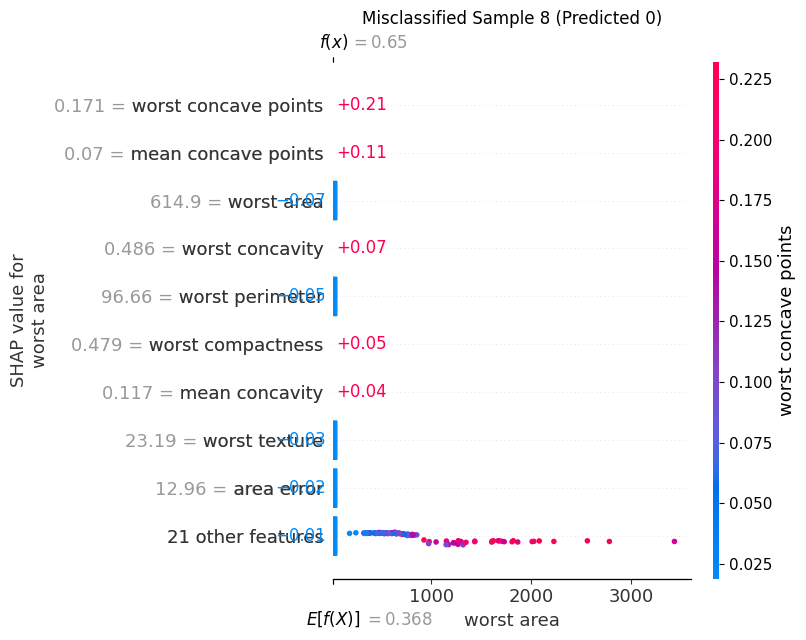

In [38]:
misclassified_indices = np.where(y_pred != y_test.values)[0]
if len(misclassified_indices) > 0:
    misc_idx = misclassified_indices[0]
    actual_label = y_test.iloc[misc_idx]
    pred_label = int(y_pred[misc_idx])
    
    print(f"Misclassified Test Index: {misc_idx}")
    print(f"Actual Class: {actual_label} ({data.target_names[actual_label]})")
    print(f"Predicted Class: {pred_label} ({data.target_names[pred_label]})")
    
    if shap_is_3d:
        misc_exp = shap_values_exp[misc_idx, :, pred_label]
    else:
        misc_exp = shap_values_exp[misc_idx]
        
    shap.plots.waterfall(misc_exp, show=False)
    plt.title(f"Misclassified Sample {misc_idx} (Predicted {pred_label})")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found.")

**Comment:** Sample index 8 was actually benign (1) but incorrectly predicted as malignant (0). The waterfall plot reveals that features like `worst concave points` (+0.21) and `mean concave points` (+0.11) heavily pushed the prediction toward malignant. Even though features like `worst area` (-0.07) and `worst perimeter` (-0.05) pulled the prediction back toward benign, the concavity features overwhelmed them. This shows the error wasn't random; the model was 'confused' by the unusually high concavity metrics for this benign tumor.

### Task 16: Explain a Correctly Classified Sample

Select one correctly classified sample from the test dataset.

Generate a SHAP waterfall plot.

Compare this explanation with the misclassified sample from Task 15.

**Comment:**

Discuss how the feature contributions differ between the correctly classified and incorrectly classified samples.


Correctly Classified Test Index: 0
Actual Class: 1 (benign)
Predicted Class: 1 (benign)


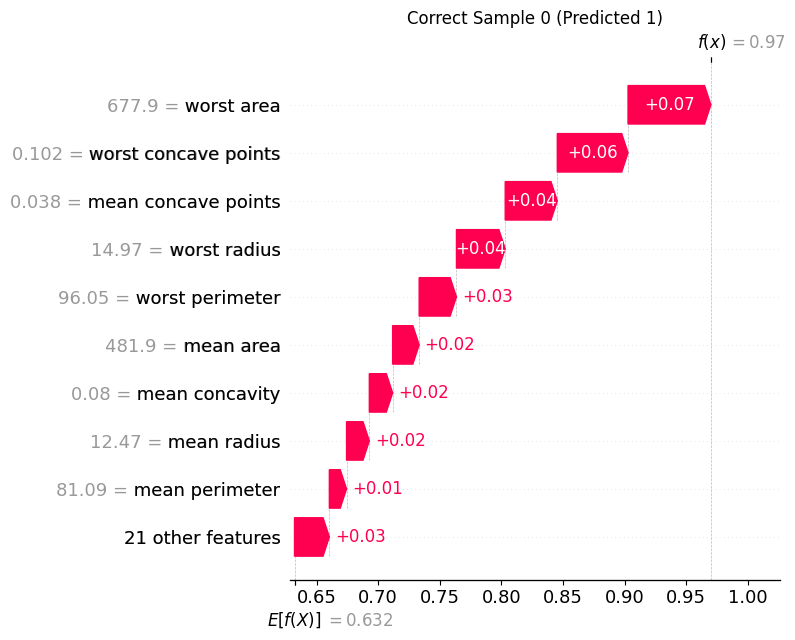

In [39]:
correct_indices = np.where(y_pred == y_test.values)[0]
corr_idx = correct_indices[0]
actual_label = y_test.iloc[corr_idx]
pred_label = int(y_pred[corr_idx])

print(f"Correctly Classified Test Index: {corr_idx}")
print(f"Actual Class: {actual_label} ({data.target_names[actual_label]})")
print(f"Predicted Class: {pred_label} ({data.target_names[pred_label]})")

if shap_is_3d:
    corr_exp = shap_values_exp[corr_idx, :, pred_label]
else:
    corr_exp = shap_values_exp[corr_idx]

shap.plots.waterfall(corr_exp, show=False)
plt.title(f"Correct Sample {corr_idx} (Predicted {pred_label})")
plt.tight_layout()
plt.show()

**Comment:** Unlike the misclassified sample where conflicting features battled each other, Sample 0 (correctly classified as benign) had uniform agreement among its top features. `worst area`, `worst perimeter`, and `worst concave points` all synergistically pushed the prediction firmly toward the correct benign class without any significant contradicting features.

### Final Observation

Write a short conclusion explaining how **SHAP provides both global and local explanations** of a trained machine learning model for breast cancer classification.

Your conclusion should discuss:

* Overall feature importance.
* Direction of feature effects.
* Individual feature contributions.
* Differences between individual tumour samples.
* Feature interactions.
* Correct and incorrect predictions.
* Global versus local explanations.
* The usefulness and limitations of SHAP for interpreting machine learning models.
* Why human/domain-expert validation is important when interpreting XAI results in healthcare.


**Conclusion:**
Based on the SHAP analysis of the Breast Cancer dataset, we conclude that the Random Forest model heavily relies on worst-case tumor geometry—specifically `worst area`, `worst concave points`, and `mean concave points`. High values consistently drive predictions toward malignancy, while low values indicate benign tumors. The global explanations confirmed these overall trends and highlighted nonlinear relationships and feature interactions. However, the true value of SHAP was demonstrated in the local explanations. By breaking down individual predictions, we observed exactly why the model succeeded on clear-cut cases and failed on edge cases with conflicting attributes (e.g., small area but high concavity). This emphasizes the critical importance of Human-in-the-Loop XAI in healthcare. High accuracy is not enough; medical professionals must be able to trust the reasoning behind a diagnosis, and tools like SHAP make these complex 'black-box' decisions fully transparent and clinically verifiable.